# HW_2

As one could tell, I genuшnуly wrote this by myself with some help from vs studio co-pilot

In [2]:
import numpy as np
import matplotlib.pyplot as plt

a = 2.49  # lattice constant Å
acc = 1.44 # C-C bond length Å

a1 = a * np.array([np.sqrt(3)/2, 1/2])
a2 = a * np.array([np.sqrt(3)/2, -1/2])

k_max = 6 #A-1
kx = np.linspace(-k_max, k_max, 300)
ky = np.linspace(-k_max, k_max, 300)



# 1 atom per cell

In [3]:
def generate_lattice_1atom(N_max):
    lattice_points = []
    for Na in range(-N_max, N_max+1):
        for Nb in range(-N_max, N_max+1):
            R = Na * a1 + Nb * a2  
            lattice_points.append(R)
    return np.array(lattice_points)

def scattering_intensity(kx, ky, lattice):
    f = 0
    for R in lattice:
        dk = np.array([kx, ky])
        f += np.exp(1j * np.dot(dk, R)) 
    return np.square(np.abs(f))

def scattering_map(kx, ky, lattice):
    scattering_map = np.zeros((len(kx), len(ky)))
    for i, kx_val in enumerate(kx):
        for j, ky_val in enumerate(ky):
            scattering_map[i, j] = scattering_intensity(kx_val, ky_val, lattice)
    return scattering_map

def number_of_cells(N_max):
    return (2 * N_max+1) ** 2


(np.float64(-9.48817432386231),
 np.float64(9.48817432386231),
 np.float64(-5.478000000000001),
 np.float64(5.478000000000001))

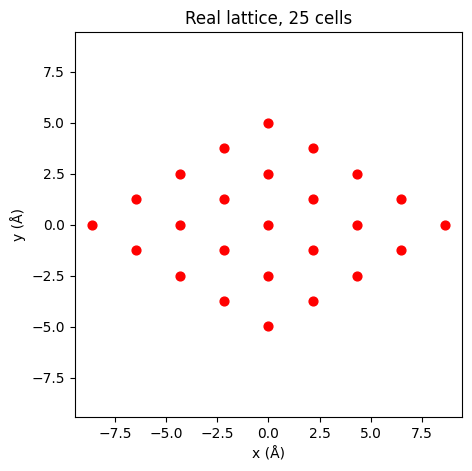

In [4]:
N_max = 2
Rs = generate_lattice_1atom(N_max)

fig = plt.figure(figsize=(5, 5))
plt.scatter([R[0] for R in Rs], [R[1] for R in Rs], color='red', s=40)
plt.title(f'Real lattice, {number_of_cells(N_max)} cells')
plt.xlabel('x (Å)')
plt.ylabel('y (Å)')
plt.axis('equal')



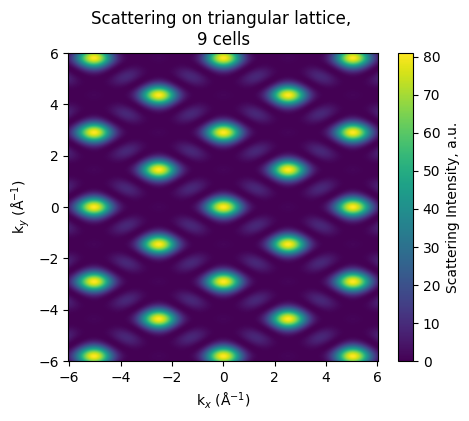

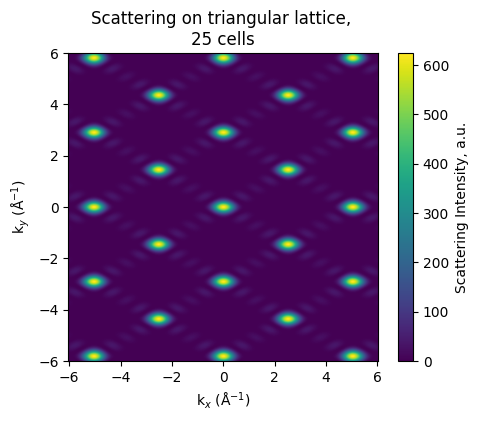

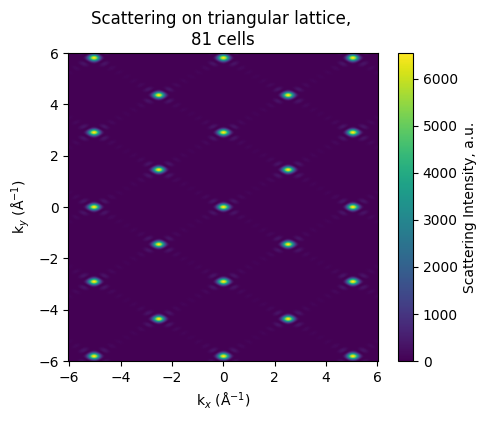

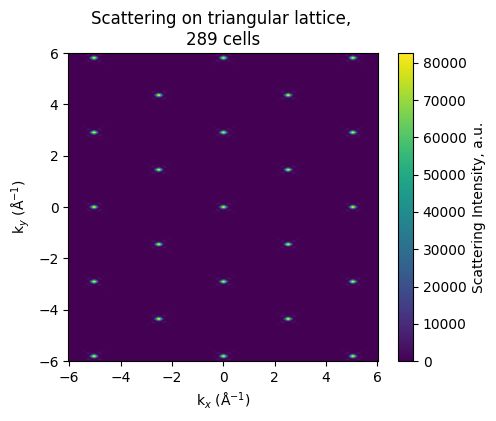

In [5]:

for N_max in [1, 2, 4, 8]:
    lattice = generate_lattice_1atom(N_max)
    vals = scattering_map(kx, ky, lattice)
    plt.figure(figsize=(5,4))
    plt.imshow(vals, extent=[-k_max, k_max, -k_max, k_max], origin='lower')
    plt.xlabel('k$_x$ (Å$^{-1}$)')
    plt.ylabel('k$_y$ (Å$^{-1}$)')
    plt.title(f'Scattering on triangular lattice, \n{number_of_cells(N_max)} cells')
    plt.colorbar(label='Scattering Intensity, a.u.')
    plt.axis('equal')
    plt.show()

# 2-atom lattice

In [6]:

def generate_lattice_2atom(N_max):
    Rs = {'A': [], 'B': []}

    basis_B = np.array([a/np.sqrt(3), 0])
    for n1 in range(-N_max, N_max + 1):
        for n2 in range(-N_max, N_max + 1):
            R_cell = n1 * a1 + n2 * a2
            # Use .tolist() or wrap in list() to ensure proper nesting
            Rs['A'].append((R_cell).tolist()) 
            Rs['B'].append((R_cell + basis_B).tolist())
    return Rs

(np.float64(-9.560054432376418),
 np.float64(10.997656602658587),
 np.float64(-5.478000000000001),
 np.float64(5.478000000000001))

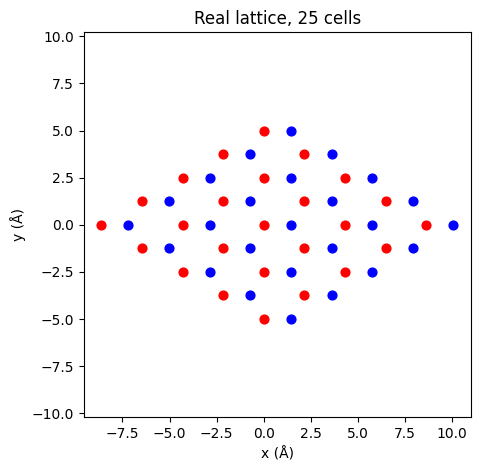

In [7]:
N_max = 2
Rs = generate_lattice_2atom(N_max)

fig = plt.figure(figsize=(5, 5))
plt.scatter([R[0] for R in np.array(Rs['A'])], [R[1] for R in np.array(Rs['A'])], color='red', s=40)
plt.scatter([R[0] for R in np.array(Rs['B'])], [R[1] for R in np.array(Rs['B'])], color='blue', s=40)

plt.title(f'Real lattice, {number_of_cells(N_max)} cells')
plt.xlabel('x (Å)')
plt.ylabel('y (Å)')
plt.axis('equal')


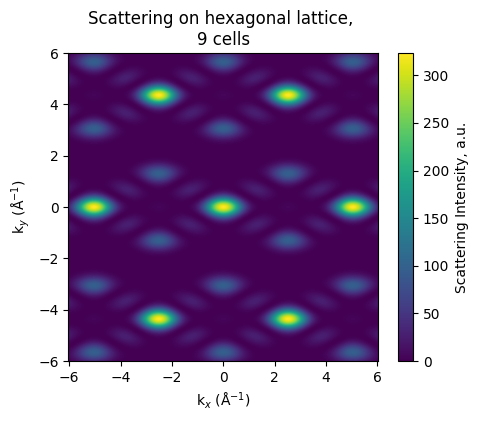

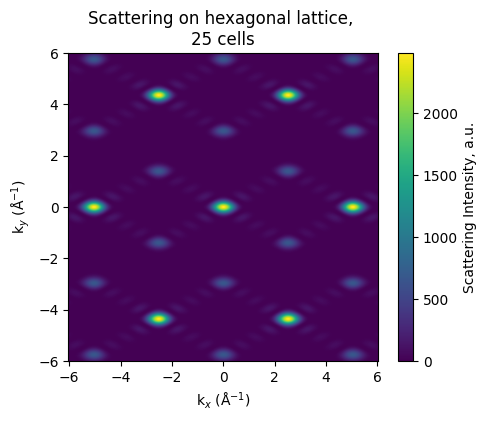

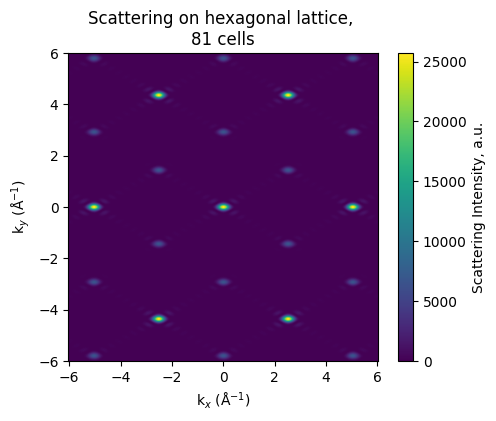

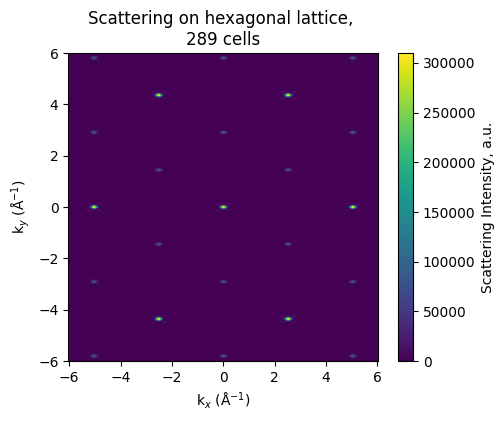

In [8]:
for N_max in [1, 2, 4, 8]:
    lattice = generate_lattice_2atom(N_max)
    lattice = np.concatenate(list(lattice.values()), axis=0) 
    vals = scattering_map(kx, ky, lattice)
    plt.figure(figsize=(5,4))
    plt.imshow(vals, extent=[-k_max, k_max, -k_max, k_max], origin='lower')
    plt.xlabel('k$_x$ (Å$^{-1}$)')
    plt.ylabel('k$_y$ (Å$^{-1}$)')
    plt.title(f'Scattering on hexagonal lattice, \n{number_of_cells(N_max)} cells')
    plt.colorbar(label='Scattering Intensity, a.u.')
    plt.axis('equal')
    plt.show()